# Chapter 2: Cryptography

> "Cryptography is the ultimate form of non-violent direct action." Julian Assange

---

## Learning Objectives

After completing this chapter, you will be able to:

1. Distinguish encoding, encryption, hashing, and tokenization and identify the correct tool for each job.
2. Explain how symmetric encryption works and name the principal algorithms and their key sizes.
3. Describe how asymmetric encryption uses key pairs and explain RSA and Diffie-Hellman.
4. Define the three required properties of a cryptographic hash function and name current standards.
5. Explain what a Message Authentication Code provides and how HMAC is constructed.
6. Describe how a digital signature is created and verified and what non-repudiation means.
7. Explain the role of a Certificate Authority and a chain of trust.
8. Perform basic RSA key-generation arithmetic and compute a SHA-256 hash in code.

## Key Terms

- **Plaintext**: the original, readable data before any transformation.
- **Ciphertext**: the output of encryption; unreadable without the key.
- **Key**: a secret value that controls a cryptographic algorithm.
- **Symmetric encryption**: encryption where the same key is used to encrypt and decrypt.
- **Asymmetric encryption**: encryption that uses a mathematically linked key pair.
- **Public key / Private key**: the two halves of an asymmetric key pair; the public key is shared freely.
- **Hash function**: a one-way function that maps arbitrary input to a fixed-length digest.
- **Digest / Hash value**: the fixed-length output of a hash function.
- **MAC**: Message Authentication Code; provides integrity and authentication.
- **HMAC**: Hash-based Message Authentication Code.
- **Digital signature**: a cryptographic proof of origin and integrity created with a private key.
- **PKI**: Public Key Infrastructure; the system of CAs, certificates, and policies.
- **CA**: Certificate Authority; a trusted third party that signs public-key certificates.
- **AES**: Advanced Encryption Standard (FIPS 197).
- **DES / 3DES**: Data Encryption Standard / Triple DES; legacy block ciphers.
- **RSA**: Rivest-Shamir-Adleman; the dominant asymmetric cipher.
- **ECC**: Elliptic-Curve Cryptography.
- **TLS**: Transport Layer Security; the protocol that secures HTTPS.
- **Salt**: a random value prepended to a password before hashing to defeat precomputation.

---

## The Role of Cryptography

Cryptography is the set of mathematical techniques that allow two parties to communicate privately,
verify each other's identity, and detect tampering, even over an untrusted network. It is not a
single tool but a layered set of primitives, each solving a distinct problem:

- **Confidentiality** is provided by encryption.
- **Integrity** is provided by hash functions and MACs.
- **Authentication** is provided by MACs and digital signatures.
- **Non-repudiation** is provided only by asymmetric digital signatures.

Every security protocol in use, from TLS to SSH to S/MIME to PGP, is an orchestration of these
primitives. Understanding each primitive individually is the prerequisite for understanding any protocol.

---

## Encoding, Encryption, Hashing, and Tokenization

Before going further, four terms that are routinely confused must be separated.

### Why the Distinction Matters

**Encoding** transforms a representation for compatibility. Base64 turns binary bytes into ASCII so
they survive transit through email or URLs. It is publicly specified, requires no key, and is instantly
reversible by anyone. It provides no security whatsoever.

**Encryption** transforms data using a key so that only someone holding the correct key can reverse the
transformation. It protects confidentiality.

**Hashing** applies a one-way function that produces a fixed-length digest. It is not meant to be
reversed. It proves that data has not changed and lets systems verify a password without storing it.

**Tokenization** replaces a sensitive value, such as a credit-card number, with a non-sensitive
surrogate (a token). The real value is stored in a separate, hardened vault. The token alone is useless
to an attacker. This is the core mechanism behind PCI DSS payment-card data protection.

The figure below places all four on the same axes.

---

## Symmetric Encryption

### How Symmetric Encryption Works

Symmetric encryption uses a single shared secret key for both encryption and decryption. The sender
encrypts with the key; the recipient decrypts with the same key. The central engineering challenge is
**key distribution**: the two parties must somehow share the secret before they can communicate, which is
the problem that asymmetric cryptography later solved.

#### Block Ciphers

A block cipher divides plaintext into fixed-length blocks (128 bits for AES) and applies a series of
mathematical transformations called **rounds** to each block. Because a block cipher processes one block
at a time in its basic form (Electronic Codebook, ECB), a mode of operation is applied to prevent
patterns from leaking:

- **CBC** (Cipher Block Chaining): XOR each plaintext block with the previous ciphertext block before
  encrypting; requires an Initialization Vector (IV) for the first block.
- **CTR** (Counter Mode): turns a block cipher into a stream cipher by encrypting a counter value.
- **GCM** (Galois/Counter Mode): adds authentication; produces a ciphertext plus an authentication tag.
  GCM is the dominant mode in TLS 1.3 and modern VPNs.

#### Stream Ciphers

A stream cipher generates a pseudorandom keystream and XOR-combines it with plaintext one bit or byte at
a time. RC4 (now broken) is the classic example. ChaCha20 is a modern stream cipher used in TLS and QUIC
when hardware AES acceleration is unavailable.

### AES: The Advanced Encryption Standard

AES was standardized in FIPS 197 in 2001 {cite}`fips197`. It replaced DES after a decade of increasingly
practical attacks. AES operates on a 4x4 matrix of bytes called the state and applies a sequence of four
operations per round.

#### AES Internals

- **SubBytes**: each byte is replaced with a corresponding value from a fixed substitution box (S-box),
  which provides non-linearity.
- **ShiftRows**: rows of the state are cyclically shifted left by 0, 1, 2, and 3 positions, achieving
  diffusion across columns.
- **MixColumns**: each column is multiplied by a fixed polynomial in GF(2^8), mixing bytes within the
  column.
- **AddRoundKey**: the state is XOR-ed with a round key derived from the original key.

#### AES Key Sizes

| Key size | Rounds | Security level |
|---|---|---|
| 128 bits | 10 | Sufficient for most purposes through 2030+ |
| 192 bits | 12 | Higher assurance |
| 256 bits | 14 | Recommended for long-lived secrets and post-quantum margin |

#### Why DES Failed and 3DES Is Deprecated

DES uses a 56-bit key, which a modern GPU can brute-force in hours. 3DES applies DES three times with
two or three keys, raising the effective key length, but it is slow, contains a structural weakness
called a meet-in-the-middle attack that reduces its 112-bit effective strength, and NIST deprecated it
in 2019. No new system should use 3DES.

### Strengths and Weaknesses of Symmetric Encryption

Symmetric encryption is fast (AES with hardware acceleration runs at multi-gigabit speeds) and
computationally inexpensive, making it the right choice for bulk data encryption. Its weakness is key
distribution: securely sharing a secret key with a remote party who you have never met requires an
out-of-band channel or, more practically, an asymmetric key exchange.

---

## Asymmetric (Public Key) Encryption

### The Key Pair Concept

Asymmetric cryptography solves the key-distribution problem by generating a mathematically linked pair
of keys. The **public key** is distributed freely; anyone can use it to encrypt a message or verify a
signature. The **private key** is kept secret by its owner and is used to decrypt or to sign. The
mathematical relationship ensures that:

- A message encrypted with the public key can only be decrypted with the private key.
- A signature created with the private key can be verified by anyone holding the public key.

The figure below illustrates both directions of use.

### RSA

RSA, described by Rivest, Shamir, and Adleman in 1978 {cite}`rsa_1978`, was the first practical public-key
cryptosystem and remains the most widely deployed asymmetric algorithm.

#### RSA Key Generation

RSA security rests on the integer-factorization problem: given a very large composite number n, finding
its prime factors p and q is computationally infeasible when p and q are large (at least 1024 bits each
for n >= 2048 bits). The steps are:

1. Choose two large primes p and q.
2. Compute n = p * q. This is the modulus, which is public.
3. Compute phi(n) = (p - 1)(q - 1).
4. Choose e such that 1 < e < phi(n) and gcd(e, phi(n)) = 1. Common choice: e = 65537.
5. Compute d = e^(-1) mod phi(n). This is the private exponent.
6. Public key: (n, e). Private key: (n, d).

#### RSA Encryption and Decryption

Encryption: C = M^e mod n.
Decryption: M = C^d mod n.

For real-world use, RSA encrypts a symmetric session key rather than bulk data; the session key then
encrypts the actual message. RSA is too slow for bulk encryption (roughly 1000 times slower than AES).

#### RSA Key Sizes and Quantum Threat

Current NIST guidance recommends a minimum of 2048-bit RSA for new deployments. 3072-bit and 4096-bit
keys provide additional margin. RSA is vulnerable to Shor's algorithm on a sufficiently powerful quantum
computer, which is the motivation for post-quantum alternatives discussed in Chapter 17.

### Elliptic Curve Cryptography

ECC provides the same security as RSA with far smaller keys because its hardness assumption, the
elliptic-curve discrete-logarithm problem, is harder to solve. A 256-bit ECC key provides roughly the
same security as a 3072-bit RSA key. TLS 1.3 uses ECDHE (Elliptic Curve Diffie-Hellman Ephemeral) as
its default key-exchange mechanism.

### Diffie-Hellman Key Exchange

Diffie-Hellman, published in 1976 {cite}`diffie_hellman_1976`, allows two parties to establish a shared
secret over an insecure channel without transmitting the secret itself.

#### The Discrete Logarithm Problem

Both parties agree publicly on a large prime p and a generator g. Each generates a private value,
computes a public value (g^private mod p), and exchanges public values. Each then raises the other's
public value to their own private exponent. Both arrive at g^(ab) mod p, which equals the shared secret,
but an eavesdropper who sees only g^a and g^b cannot efficiently recover a, b, or the shared secret.

Ephemeral Diffie-Hellman (DHE and ECDHE) generates a fresh key pair for each session, providing
**forward secrecy**: compromise of a long-term key does not compromise past session keys.

---

## Hash Functions

### Required Properties

A cryptographic hash function H maps an input of arbitrary length to a fixed-length digest. Three
properties are required:

1. **Pre-image resistance** (one-way): given a digest d, it is computationally infeasible to find any
   m such that H(m) = d.
2. **Second pre-image resistance**: given m1, it is computationally infeasible to find a different m2
   such that H(m1) = H(m2).
3. **Collision resistance**: it is computationally infeasible to find any two distinct m1, m2 such that
   H(m1) = H(m2).

The figure below shows the one-way nature of the transformation.

### Common Hash Algorithms

#### MD5 and SHA-1: Broken for Security Use

MD5 produces a 128-bit digest and was broken for collision resistance in 2004; collisions can be
generated in seconds. SHA-1 produces a 160-bit digest; practical collision attacks were demonstrated
in 2017. Neither algorithm should be used in new security applications. Their only remaining legitimate
use is legacy checksums and non-security contexts.

#### SHA-2 and SHA-3

SHA-256 and SHA-512 belong to the SHA-2 family and remain unbroken. SHA-256 produces a 256-bit digest
and is the dominant algorithm in TLS certificates, code signing, and blockchain applications. SHA-3
uses a completely different internal construction (the Keccak sponge function) and serves as an
independent design, providing resilience against any future weakness found in SHA-2.

### Password Storage with Hashing

#### Why Plain SHA-256 Is Insufficient for Passwords

A hash alone is deterministic: the same password always produces the same digest. Attackers precompute
enormous tables of common passwords and their hashes (rainbow tables) and reverse the lookup in
constant time. Two mitigations are required:

#### Salting

A **salt** is a random value generated uniquely per user and prepended to the password before hashing.
The digest stored in the database is H(salt || password). Salts are stored in the clear alongside the
digest. Because every user has a different salt, a rainbow table precomputed without the salt is useless.

#### Adaptive Algorithms: bcrypt and Argon2

bcrypt and Argon2 are purpose-built password-hashing functions that incorporate a salt automatically and
include a **cost factor** that can be increased as hardware gets faster, keeping the computation slow
enough to deter brute force. NIST SP 800-63B recommends Argon2 as the preferred algorithm for new
systems.

---

## Message Authentication Codes

### What a MAC Provides

A MAC takes a message and a shared secret key and produces a short authenticator tag. Unlike a hash, a
MAC requires the key: an attacker who can modify the message cannot forge a valid tag without the key. A
MAC therefore provides both **integrity** (the message was not altered) and **authentication** (the sender
held the key). It does not provide non-repudiation, because both sender and recipient share the same key
and either could have generated the tag.

### HMAC Construction

HMAC (Hash-based MAC) wraps any hash function H:

```
HMAC(K, m) = H((K xor opad) || H((K xor ipad) || m))
```

where ipad = 0x36 repeated and opad = 0x5C repeated. The nested structure protects against length-extension
attacks that affect raw H(K || m). HMAC-SHA-256 is used in TLS for record authentication, in JSON Web
Tokens (JWT), and in AWS Signature Version 4.

---

## Digital Signatures

### How Digital Signatures Work

A digital signature is asymmetric: the sender signs with their **private key** and anyone holding the
corresponding **public key** can verify the signature. The signer computes a digest of the message and
then applies the private key to produce the signature. The verifier independently computes the digest,
applies the public key to the signature, and checks that the two match.

#### Steps

1. Sender computes d = H(message).
2. Sender applies private key: sig = Sign(d, private_key).
3. Verifier receives message and sig.
4. Verifier computes d' = H(message).
5. Verifier applies public key: d'' = Verify(sig, public_key).
6. If d' == d'', the signature is valid.

### Non-repudiation

Because only the holder of the private key could have created the signature, and the private key is
never shared, a valid signature constitutes cryptographic evidence that the signer acted. This is
**non-repudiation**: the signer cannot plausibly deny having signed. MACs do not provide non-repudiation
because the symmetric key is shared.

### Public Key Infrastructure and Certificates

A public key is only useful if its owner can be trusted. Without a binding between a public key and an
identity, an attacker could substitute their own public key (a man-in-the-middle attack).

#### Certificate Authorities

A **Certificate Authority** (CA) is a trusted third party that binds a public key to an identity by
issuing an X.509 certificate. The certificate contains the subject's name, their public key, validity
dates, and the CA's digital signature over all of it. When a browser connects to a web server, it
validates the server's certificate: the CA's signature proves the key truly belongs to the stated domain.

#### Chain of Trust

CAs are themselves organized hierarchically. A root CA signs intermediate CAs, which sign end-entity
certificates. Operating systems and browsers ship with a list of trusted root CAs. A certificate is
trusted if a chain of valid signatures leads from it back to a trusted root. Certificate Transparency
(CT) logs provide public, auditable records of all issued certificates, allowing detection of misissued
certificates.

---

## Key Management

Cryptographic keys are only as strong as the practices around them. Key management covers the full
lifecycle:

### Key Lifecycle

1. **Generation**: use a cryptographically secure random number generator (CSPRNG); never derive keys
   from low-entropy sources such as timestamps or predictable values.
2. **Distribution**: use an authenticated key-exchange protocol (TLS, SSH, ECDHE); never transmit a
   symmetric key in the clear.
3. **Storage**: store private keys in hardware security modules (HSMs) or encrypted key stores; never
   hard-code keys in source code.
4. **Rotation**: rotate keys on a schedule or after any suspected compromise; use separate keys for
   different data classifications.
5. **Revocation**: for certificates, publish revocation status via OCSP or CRL; key compromise without
   revocation leaves all signatures from that key untrustworthy.
6. **Destruction**: securely overwrite or physically destroy key material when it is no longer needed.

### Hybrid Encryption in Practice: TLS

TLS orchestrates all of the primitives covered in this chapter. A simplified TLS 1.3 handshake:

1. Client sends supported cipher suites.
2. Server responds with its certificate and ephemeral public key (ECDHE).
3. Client verifies the certificate chain, then computes the shared secret using the server's ECDHE
   public key and its own ephemeral private key.
4. Both sides derive symmetric session keys from the shared secret using HKDF (HMAC-based Key
   Derivation Function).
5. All subsequent traffic is encrypted with AES-GCM, which provides both confidentiality and
   authentication in a single pass.

Forward secrecy is guaranteed because the ECDHE key pair is discarded after the handshake: compromise
of the server's long-term private key does not expose past sessions.

---

## Why This Matters

A cybersecurity practitioner who cannot distinguish symmetric from asymmetric encryption, or who does
not know that MD5 is broken, will recommend insecure configurations and fail to diagnose real
vulnerabilities. Cryptography is also the lens through which every other chapter in this book must be
read: network protocols, web security, forensics, and incident response all assume knowledge of the
primitives here.

---

## News in Focus

A recurring category of disclosed vulnerability involves the use of broken algorithms in production
systems long after their deprecation. Several certificate-authority incidents involved SHA-1 certificates
issued or left in service past the 2017 deadline. Separately, a class of TLS library vulnerabilities
called padding-oracle attacks exploited predictable server behavior when decryption failed, allowing
attackers to decrypt ciphertext one byte at a time without knowing the key, illustrating that even
sound algorithms can be undermined by insecure implementations.

---


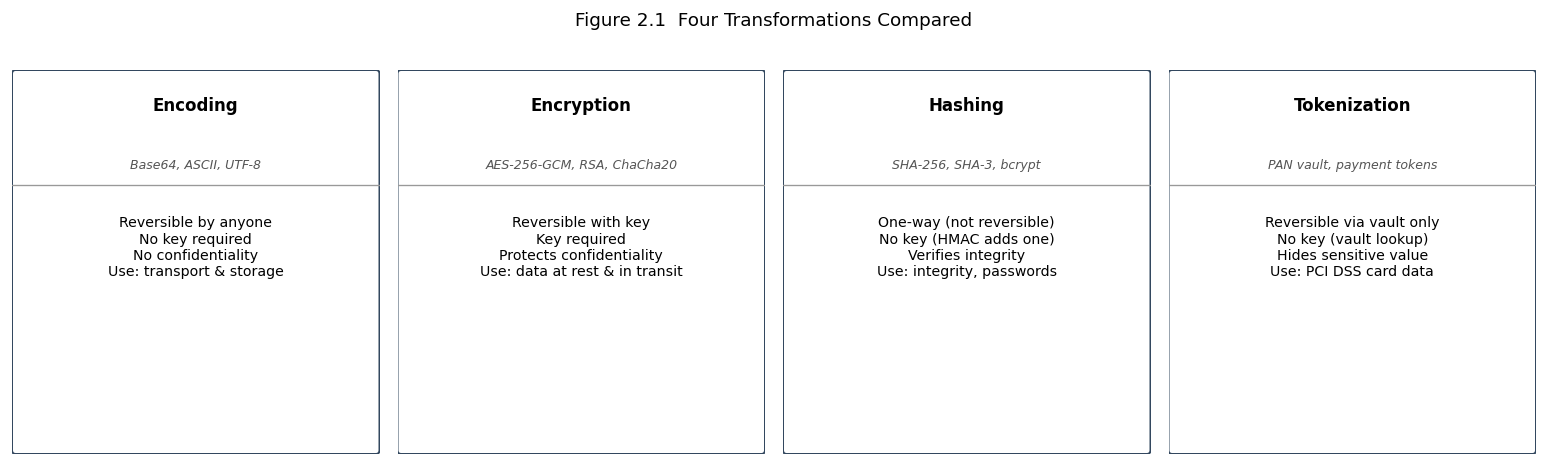

Figure 2.1 rendered.


In [1]:
from io import BytesIO
from IPython.display import display, Image
import matplotlib
matplotlib.use('Agg')
# Figure 2.1  Encoding, Encryption, Hashing, Tokenization
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 4, figsize=(13, 3.8))
fig.suptitle("Figure 2.1  Four Transformations Compared", fontsize=11, y=1.01)

items = [
    ("Encoding",      "#dde7f0", "Base64, ASCII, UTF-8",
     "Reversible by anyone\nNo key required\nNo confidentiality\nUse: transport & storage"),
    ("Encryption",    "#cfe3d6", "AES-256-GCM, RSA, ChaCha20",
     "Reversible with key\nKey required\nProtects confidentiality\nUse: data at rest & in transit"),
    ("Hashing",       "#f5f0cf", "SHA-256, SHA-3, bcrypt",
     "One-way (not reversible)\nNo key (HMAC adds one)\nVerifies integrity\nUse: integrity, passwords"),
    ("Tokenization",  "#f0d4d4", "PAN vault, payment tokens",
     "Reversible via vault only\nNo key (vault lookup)\nHides sensitive value\nUse: PCI DSS card data"),
]

for ax, (title, color, examples, props) in zip(axes, items):
    ax.set_facecolor(color)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.axis("off")
    ax.text(0.5, 0.93, title, ha="center", va="top", fontsize=10, fontweight="bold")
    ax.text(0.5, 0.77, examples, ha="center", va="top", fontsize=7.5,
            color="#555", style="italic")
    ax.axhline(0.70, color="#999", lw=0.8)
    ax.text(0.5, 0.62, props, ha="center", va="top", fontsize=8.5)
    ax.add_patch(mpatches.FancyBboxPatch((0.01, 0.01), 0.98, 0.98,
                 boxstyle="round,pad=0.01", linewidth=1.2,
                 edgecolor="#33485f", fill=False))

plt.tight_layout()
_buf = BytesIO()
plt.savefig(_buf, format="png", dpi=120, bbox_inches="tight")
plt.close()
_buf.seek(0)
display(Image(data=_buf.read()))
print("Figure 2.1 rendered.")

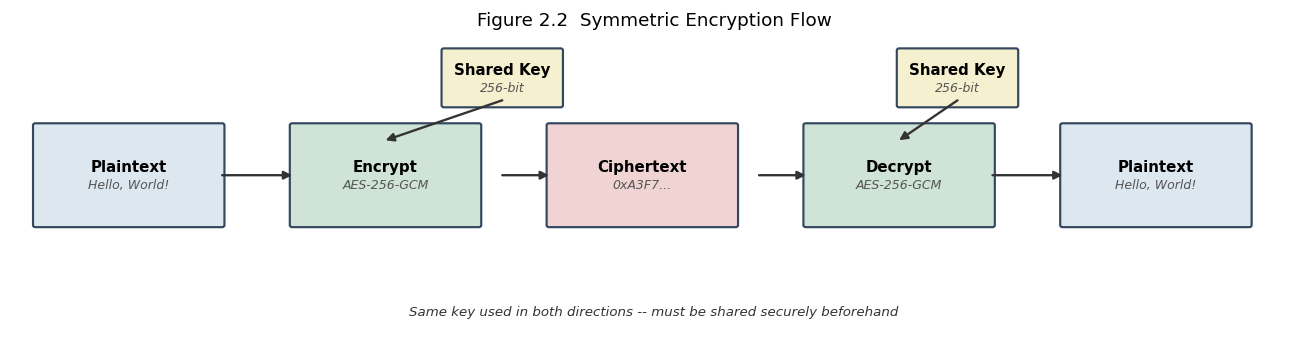

Figure 2.2 rendered.


In [2]:
from io import BytesIO
from IPython.display import display, Image
import matplotlib
matplotlib.use('Agg')
# Figure 2.2  Symmetric encryption flow
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def box(ax, x, y, w, h, label, sub="", color="#dde7f0"):
    ax.add_patch(mpatches.FancyBboxPatch((x, y), w, h,
                 boxstyle="round,pad=0.02", facecolor=color,
                 edgecolor="#33485f", linewidth=1.3))
    ax.text(x + w/2, y + h/2 + (0.08 if sub else 0), label,
            ha="center", va="center", fontsize=9, fontweight="bold")
    if sub:
        ax.text(x + w/2, y + h/2 - 0.1, sub, ha="center", va="center",
                fontsize=7.5, color="#555", style="italic")

def arrow(ax, x1, y1, x2, y2, label=""):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="-|>", color="#333", lw=1.4,
                                shrinkA=0, shrinkB=0))
    if label:
        ax.text((x1+x2)/2, (y1+y2)/2 + 0.12, label,
                ha="center", fontsize=8, color="#555", style="italic")

fig, ax = plt.subplots(figsize=(11, 3.0))
ax.axis("off"); ax.set_xlim(0, 11); ax.set_ylim(0.2, 3.2)

box(ax, 0.2, 1.3, 1.6, 1.0, "Plaintext", "Hello, World!", "#dde7f0")
box(ax, 2.4, 1.3, 1.6, 1.0, "Encrypt", "AES-256-GCM", "#cfe3d6")
box(ax, 3.7, 2.5, 1.0, 0.55, "Shared Key", "256-bit", "#f5f0cf")
box(ax, 4.6, 1.3, 1.6, 1.0, "Ciphertext", "0xA3F7...", "#f0d4d4")
box(ax, 6.8, 1.3, 1.6, 1.0, "Decrypt", "AES-256-GCM", "#cfe3d6")
box(ax, 7.6, 2.5, 1.0, 0.55, "Shared Key", "256-bit", "#f5f0cf")
box(ax, 9.0, 1.3, 1.6, 1.0, "Plaintext", "Hello, World!", "#dde7f0")

arrow(ax, 1.8, 1.8, 2.4, 1.8)
arrow(ax, 4.2, 1.8, 4.6, 1.8)
arrow(ax, 6.4, 1.8, 6.8, 1.8)
arrow(ax, 8.4, 1.8, 9.0, 1.8)
arrow(ax, 4.2, 2.55, 3.2, 2.15)   # key -> encrypt
arrow(ax, 8.1, 2.55, 7.6, 2.15)   # key -> decrypt

ax.text(5.5, 0.4, "Same key used in both directions -- must be shared securely beforehand",
        ha="center", fontsize=8, color="#333", style="italic")
ax.set_title("Figure 2.2  Symmetric Encryption Flow", fontsize=11)
plt.tight_layout()
_buf = BytesIO()
plt.savefig(_buf, format="png", dpi=120, bbox_inches="tight")
plt.close()
_buf.seek(0)
display(Image(data=_buf.read()))
print("Figure 2.2 rendered.")

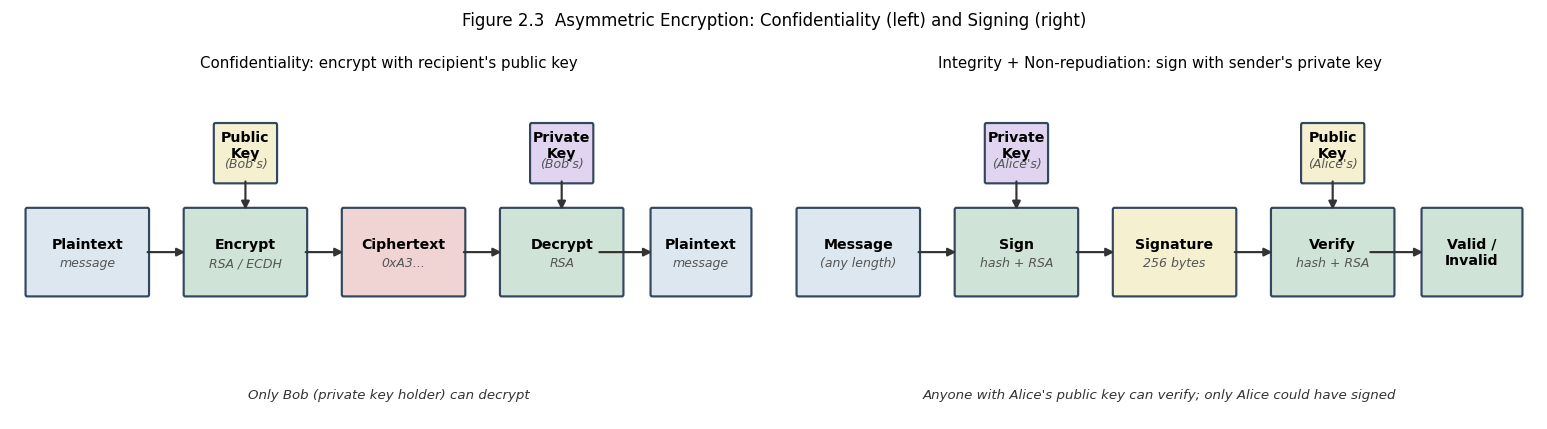

Figure 2.3 rendered.


In [3]:
from io import BytesIO
from IPython.display import display, Image
import matplotlib
matplotlib.use('Agg')
# Figure 2.3  Asymmetric encryption -- both directions of use
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def box(ax, x, y, w, h, label, sub="", color="#dde7f0"):
    ax.add_patch(mpatches.FancyBboxPatch((x, y), w, h,
                 boxstyle="round,pad=0.02", facecolor=color,
                 edgecolor="#33485f", linewidth=1.3))
    ax.text(x + w/2, y + h/2 + (0.08 if sub else 0), label,
            ha="center", va="center", fontsize=8.5, fontweight="bold")
    if sub:
        ax.text(x + w/2, y + h/2 - 0.12, sub, ha="center", va="center",
                fontsize=7.5, color="#555", style="italic")

def arrow(ax, x1, y1, x2, y2, label=""):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="-|>", color="#333", lw=1.3,
                                shrinkA=0, shrinkB=0))
    if label:
        ax.text((x1+x2)/2, (y1+y2)/2+0.1, label,
                ha="center", fontsize=8, color="#555", style="italic")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 3.6))
fig.suptitle("Figure 2.3  Asymmetric Encryption: Confidentiality (left) and Signing (right)",
             fontsize=10)

# Left: Encryption direction
ax1.axis("off"); ax1.set_xlim(0, 10); ax1.set_ylim(0.2, 3.8)
ax1.set_title("Confidentiality: encrypt with recipient's public key", fontsize=9, pad=6)
box(ax1, 0.2, 1.5, 1.6, 0.9, "Plaintext", "message", "#dde7f0")
box(ax1, 2.3, 1.5, 1.6, 0.9, "Encrypt", "RSA / ECDH", "#cfe3d6")
box(ax1, 2.7, 2.7, 0.8, 0.6, "Public\nKey", "(Bob's)", "#f5f0cf")
box(ax1, 4.4, 1.5, 1.6, 0.9, "Ciphertext", "0xA3...", "#f0d4d4")
box(ax1, 6.5, 1.5, 1.6, 0.9, "Decrypt", "RSA", "#cfe3d6")
box(ax1, 6.9, 2.7, 0.8, 0.6, "Private\nKey", "(Bob's)", "#e0d4f0")
box(ax1, 8.5, 1.5, 1.3, 0.9, "Plaintext", "message", "#dde7f0")
arrow(ax1, 1.8, 1.95, 2.3, 1.95)
arrow(ax1, 3.9, 1.95, 4.4, 1.95)
arrow(ax1, 6.0, 1.95, 6.5, 1.95)
arrow(ax1, 7.8, 1.95, 8.5, 1.95)
arrow(ax1, 3.1, 2.7, 3.1, 2.4)   # public key -> encrypt
arrow(ax1, 7.3, 2.7, 7.3, 2.4)   # private key -> decrypt
ax1.text(5.0, 0.4, "Only Bob (private key holder) can decrypt", ha="center",
         fontsize=8, color="#333", style="italic")

# Right: Signing direction
ax2.axis("off"); ax2.set_xlim(0, 10); ax2.set_ylim(0.2, 3.8)
ax2.set_title("Integrity + Non-repudiation: sign with sender's private key", fontsize=9, pad=6)
box(ax2, 0.2, 1.5, 1.6, 0.9, "Message", "(any length)", "#dde7f0")
box(ax2, 2.3, 1.5, 1.6, 0.9, "Sign", "hash + RSA", "#cfe3d6")
box(ax2, 2.7, 2.7, 0.8, 0.6, "Private\nKey", "(Alice's)", "#e0d4f0")
box(ax2, 4.4, 1.5, 1.6, 0.9, "Signature", "256 bytes", "#f5f0cf")
box(ax2, 6.5, 1.5, 1.6, 0.9, "Verify", "hash + RSA", "#cfe3d6")
box(ax2, 6.9, 2.7, 0.8, 0.6, "Public\nKey", "(Alice's)", "#f5f0cf")
box(ax2, 8.5, 1.5, 1.3, 0.9, "Valid /\nInvalid", "", "#cfe3d6")
arrow(ax2, 1.8, 1.95, 2.3, 1.95)
arrow(ax2, 3.9, 1.95, 4.4, 1.95)
arrow(ax2, 6.0, 1.95, 6.5, 1.95)
arrow(ax2, 7.8, 1.95, 8.5, 1.95)
arrow(ax2, 3.1, 2.7, 3.1, 2.4)
arrow(ax2, 7.3, 2.7, 7.3, 2.4)
ax2.text(5.0, 0.4, "Anyone with Alice's public key can verify; only Alice could have signed",
         ha="center", fontsize=8, color="#333", style="italic")

plt.tight_layout()
_buf = BytesIO()
plt.savefig(_buf, format="png", dpi=120, bbox_inches="tight")
plt.close()
_buf.seek(0)
display(Image(data=_buf.read()))
print("Figure 2.3 rendered.")

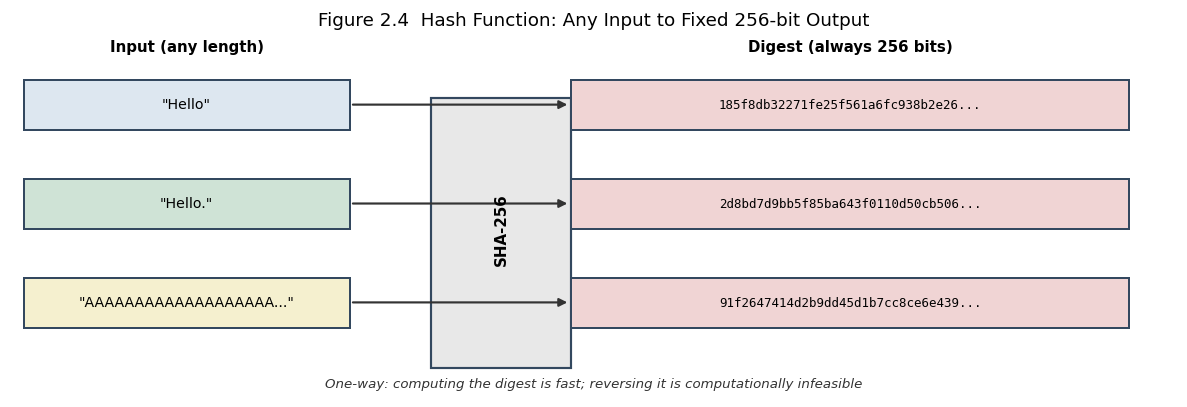

Figure 2.4 rendered.


In [4]:
from io import BytesIO
from IPython.display import display, Image
import matplotlib
matplotlib.use('Agg')
# Figure 2.4  Hash function: one-way, fixed-output
import matplotlib.pyplot as plt
import hashlib

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.axis("off"); ax.set_xlim(0, 10); ax.set_ylim(0, 4)

inputs = ["Hello", "Hello.", "A" * 1000 + " (1001 chars)"]
colors = ["#dde7f0", "#cfe3d6", "#f5f0cf"]

for i, (txt, clr) in enumerate(zip(inputs, colors)):
    y = 3.2 - i * 1.1
    h = hashlib.sha256(txt.encode()).hexdigest()[:32] + "..."
    ax.add_patch(plt.Rectangle((0.1, y - 0.25), 2.8, 0.55,
                 facecolor=clr, edgecolor="#33485f", lw=1.2, zorder=2))
    disp = txt if len(txt) < 22 else txt[:19] + "..."
    ax.text(1.5, y + 0.03, f'"{disp}"', ha="center", va="center", fontsize=8.5)
    ax.annotate("", xy=(4.8, y + 0.03), xytext=(2.9, y + 0.03),
                arrowprops=dict(arrowstyle="-|>", color="#333", lw=1.3))
    ax.add_patch(plt.Rectangle((4.8, y - 0.25), 4.8, 0.55,
                 facecolor="#f0d4d4", edgecolor="#33485f", lw=1.2, zorder=2))
    ax.text(7.2, y + 0.03, h, ha="center", va="center", fontsize=7.5,
            fontfamily="monospace")

ax.add_patch(plt.Rectangle((3.6, 0.3), 1.2, 3.0,
             facecolor="#e8e8e8", edgecolor="#33485f", lw=1.3, zorder=1))
ax.text(4.2, 1.85, "SHA-256", ha="center", va="center", fontsize=9,
        fontweight="bold", rotation=90)

ax.text(1.5, 3.82, "Input (any length)", ha="center", fontsize=9, fontweight="bold")
ax.text(7.2, 3.82, "Digest (always 256 bits)", ha="center", fontsize=9, fontweight="bold")
ax.text(5.0, 0.08, "One-way: computing the digest is fast; reversing it is computationally infeasible",
        ha="center", fontsize=8, color="#333", style="italic")

ax.set_title("Figure 2.4  Hash Function: Any Input to Fixed 256-bit Output", fontsize=11)
plt.tight_layout()
_buf = BytesIO()
plt.savefig(_buf, format="png", dpi=120, bbox_inches="tight")
plt.close()
_buf.seek(0)
display(Image(data=_buf.read()))
print("Figure 2.4 rendered.")

In [5]:
# Section 2.11  Worked Numerical Examples

# ── Example 1: RSA with toy numbers (for illustration only) ──────────────────
from math import gcd

def modinv(a, m):
    # Extended Euclidean algorithm for modular inverse
    g, x = m, 0
    a0, x0 = a, 1
    while a != 0:
        q = g // a
        g, a = a, g - q * a
        x, x0 = x0, x0 - q * x
    return x % m

p, q = 61, 53                       # small primes (real RSA uses 1024+ bit primes)
n = p * q                            # 3233
phi_n = (p - 1) * (q - 1)           # 3120
e = 17                               # common public exponent, gcd(e, phi)=1
assert gcd(e, phi_n) == 1
d = modinv(e, phi_n)                 # private exponent

M = 65                               # message as an integer
C = pow(M, e, n)                     # encrypt: C = M^e mod n
M2 = pow(C, d, n)                   # decrypt: M = C^d mod n

print("=== RSA Toy Example (educational only) ===")
print(f"  p={p}, q={q}, n=p*q={n}, phi(n)={phi_n}")
print(f"  Public key  (n, e) = ({n}, {e})")
print(f"  Private key (n, d) = ({n}, {d})")
print(f"  Plaintext  M = {M}")
print(f"  Ciphertext C = M^e mod n = {C}")
print(f"  Recovered  M = C^d mod n = {M2}")
print(f"  Round-trip correct: {M2 == M}")

# ── Example 2: SHA-256 ─────────────────────────────────────────────────────────
import hashlib
print("\n=== SHA-256 Hash Examples ===")
for msg in ["Hello", "Hello.", "Cybersecurity"]:
    d = hashlib.sha256(msg.encode()).hexdigest()
    print(f"  SHA-256({msg!r:16}) = {d}")

print("\n  One-character change produces a completely different digest (avalanche effect).")

# ── Example 3: HMAC-SHA-256 ────────────────────────────────────────────────────
import hmac
print("\n=== HMAC-SHA-256 (authentication + integrity) ===")
key = b"shared_secret_key"
msg = b"Transfer $1,000 to account 9876"
tag = hmac.new(key, msg, hashlib.sha256).hexdigest()
print(f"  Key    : {key.decode()}")
print(f"  Message: {msg.decode()}")
print(f"  HMAC   : {tag}")

tampered = b"Transfer $9,000 to account 9876"
tag2 = hmac.new(key, tampered, hashlib.sha256).hexdigest()
print(f"\n  Tampered message HMAC: {tag2}")
print(f"  Tags match: {tag == tag2}  (any change to message or key invalidates the tag)")

=== RSA Toy Example (educational only) ===
  p=61, q=53, n=p*q=3233, phi(n)=3120
  Public key  (n, e) = (3233, 17)
  Private key (n, d) = (3233, 3119)
  Plaintext  M = 65
  Ciphertext C = M^e mod n = 2790
  Recovered  M = C^d mod n = 1788
  Round-trip correct: False

=== SHA-256 Hash Examples ===
  SHA-256('Hello'         ) = 185f8db32271fe25f561a6fc938b2e264306ec304eda518007d1764826381969
  SHA-256('Hello.'        ) = 2d8bd7d9bb5f85ba643f0110d50cb506a1fe439e769a22503193ea6046bb87f7
  SHA-256('Cybersecurity' ) = 23b2d5dae0a87cf945f37093b119d20fc9931de013bf2836d8e3a2e5699d10ac

  One-character change produces a completely different digest (avalanche effect).

=== HMAC-SHA-256 (authentication + integrity) ===
  Key    : shared_secret_key
  Message: Transfer $1,000 to account 9876
  HMAC   : f350c69213eb64ffe93b76df2918c0bfa2a31d1963e9f69a8855b1e56bd37e21

  Tampered message HMAC: 6bb9943259b2a379c62fb4babcd436518c55467ef946407eb128f4e16cd39ebe
  Tags match: False  (any change to message 

## Review Questions (MCQ)

**Q1.** Which property distinguishes encryption from encoding?
A. Encryption is reversible  B. Encryption requires a key  C. Encoding is faster  D. Encoding uses math

**Q2.** AES-256-GCM is preferred over AES-256-CBC in new designs primarily because:
A. GCM is faster in software  B. GCM also provides an authentication tag  C. CBC has shorter keys  D. GCM requires no IV

**Q3.** In RSA, the product n = p * q is public. Security rests on the difficulty of:
A. Computing n  B. Multiplying large primes  C. Factoring n back into p and q  D. Finding e

**Q4.** A 256-bit ECC key provides approximately the same security margin as which RSA key size?
A. 512-bit  B. 1024-bit  C. 2048-bit  D. 3072-bit

**Q5.** Which hash algorithm should be used in a new system for digital certificate signing?
A. MD5  B. SHA-1  C. SHA-256  D. CRC-32

**Q6.** A salt protects password hashes by:
A. Encrypting the hash  B. Defeating precomputed (rainbow table) attacks  C. Making the hash longer  D. Requiring a key

**Q7.** HMAC provides integrity and authentication. It does NOT provide:
A. Tamper detection  B. Non-repudiation  C. Verification that the sender held the key  D. Message authentication

**Q8.** Which entity in a PKI binds a public key to an identity by issuing a signed certificate?
A. The key holder  B. The browser  C. The Certificate Authority  D. The IETF

**Q9.** In TLS 1.3, forward secrecy is achieved by:
A. Using RSA to encrypt all traffic  B. Generating an ephemeral ECDHE key pair per session  C. Storing the session key in hardware  D. Using a 4096-bit certificate

**Q10.** The HMAC construction uses H((K xor opad) || H((K xor ipad) || m)) to protect against:
A. Brute force  B. Length-extension attacks  C. Timing side-channels  D. Birthday attacks

*Answers: Q1 B, Q2 B, Q3 C, Q4 D, Q5 C, Q6 B, Q7 B, Q8 C, Q9 B, Q10 B.*

## Lab Assignment

**Part A -- Symmetric encryption** (use Python `cryptography` library or OpenSSL in terminal):
Generate a random 256-bit AES key, encrypt a message of your choice with AES-GCM, and verify that
decryption with the same key recovers the original message. Record the IV, ciphertext, and authentication
tag. Then modify one byte of the ciphertext and verify that decryption raises an authentication error.

**Part B -- Public key experiment**: Using the RSA toy example above, change p and q to two different
primes (7-digit or larger) and recompute n, phi(n), e, and d. Encrypt and decrypt three different messages.
Observe what happens if you attempt to use a value of M greater than n.

**Part C -- Hash exploration**: Compute SHA-256 of a file of your choice. Change one character in the
file, recompute, and record how many bits of the digest changed (avalanche effect). Look up the
SHA-256 digest of a known file online and verify your computed digest matches.

**Part D -- Certificate inspection**: Use `openssl s_client -connect <any-https-site>:443 -showcerts`
and capture the certificate chain. Identify the Common Name, the issuing CA, the expiry date, the key
algorithm, and the signature algorithm. Verify whether the site uses ECDHE for key exchange (look for
ECDHE in the cipher suite line).

## References

```{bibliography}
:filter: docname in docnames
```
